Milestone 1: Data Acquisition, Cleaning & Initial Exploration

1️⃣ Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 

2️⃣ Load Dataset

In [5]:
df = pd.read_csv("us_disaster_declarations.csv")
df.head()

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,place_code,designated_area,declaration_request_number,last_ia_filing_date,incident_id,region,designated_incident_types,last_refresh,hash,id
0,DR-1-GA,1,GA,DR,1953-05-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53013,NaN,53013,4,NaN,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2
1,DR-2-TX,2,TX,DR,1953-05-15T00:00:00Z,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,Statewide,53003,NaN,53003,6,W,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8
2,DR-3-LA,3,LA,DR,1953-05-29T00:00:00Z,1953,Flood,Flood,0,1,...,0,Statewide,53005,NaN,53005,6,NaN,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265
3,DR-4-MI,4,MI,DR,1953-06-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53004,NaN,53004,5,NaN,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6
4,DR-5-MT,5,MT,DR,1953-06-06T00:00:00Z,1953,Flood,Floods,0,1,...,0,Statewide,53006,NaN,53006,8,NaN,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4


3️⃣ Inspect Dataset

In [6]:
df.info()
df.describe()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 68485 entries, 0 to 68484
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   fema_declaration_string     68485 non-null  str  
 1   disaster_number             68485 non-null  int64
 2   state                       68485 non-null  str  
 3   declaration_type            68485 non-null  str  
 4   declaration_date            68485 non-null  str  
 5   fy_declared                 68485 non-null  int64
 6   incident_type               68485 non-null  str  
 7   declaration_title           68485 non-null  str  
 8   ih_program_declared         68485 non-null  int64
 9   ia_program_declared         68485 non-null  int64
 10  pa_program_declared         68485 non-null  int64
 11  hm_program_declared         68485 non-null  int64
 12  incident_begin_date         68485 non-null  str  
 13  incident_end_date           67963 non-null  str  
 14  disaster_closeout

Index(['fema_declaration_string', 'disaster_number', 'state',
       'declaration_type', 'declaration_date', 'fy_declared', 'incident_type',
       'declaration_title', 'ih_program_declared', 'ia_program_declared',
       'pa_program_declared', 'hm_program_declared', 'incident_begin_date',
       'incident_end_date', 'disaster_closeout_date', 'tribal_request', 'fips',
       'place_code', 'designated_area', 'declaration_request_number',
       'last_ia_filing_date', 'incident_id', 'region',
       'designated_incident_types', 'last_refresh', 'hash', 'id'],
      dtype='str')

4️⃣ Check Missing Values

In [12]:
df.isnull().sum()

fema_declaration_string       0
disaster_number               0
state                         0
declaration_type              0
declaration_date              0
fy_declared                   0
incident_type                 0
declaration_title             0
ih_program_declared           0
ia_program_declared           0
pa_program_declared           0
hm_program_declared           0
incident_begin_date           0
tribal_request                0
fips                          0
place_code                    0
designated_area               0
declaration_request_number    0
incident_id                   0
region                        0
last_refresh                  0
hash                          0
id                            0
dtype: int64

5️⃣ Handle Missing Values

In [16]:
df = df.dropna(subset=['declaration_date'])

In [17]:
df

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,tribal_request,fips,place_code,designated_area,declaration_request_number,incident_id,region,last_refresh,hash,id
0,DR-1-GA,1,GA,DR,1953-05-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,13000,0,Statewide,53013,53013,4,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2
1,DR-2-TX,2,TX,DR,1953-05-15T00:00:00Z,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,48000,0,Statewide,53003,53003,6,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8
2,DR-3-LA,3,LA,DR,1953-05-29T00:00:00Z,1953,Flood,Flood,0,1,...,0,22000,0,Statewide,53005,53005,6,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265
3,DR-4-MI,4,MI,DR,1953-06-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,26000,0,Statewide,53004,53004,5,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6
4,DR-5-MT,5,MT,DR,1953-06-06T00:00:00Z,1953,Flood,Floods,0,1,...,0,30000,0,Statewide,53006,53006,8,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68480,DR-4892-WI,4892,WI,DR,2025-09-11T00:00:00Z,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,0,55131,99131,Washington (County),25120,2025081401,5,2025-09-12T12:21:22Z,22cc4f080a3606258847520b92c4b060e755169d,e411afd4-9728-4e8f-92d7-5297a68d9d61
68481,DR-4892-WI,4892,WI,DR,2025-09-11T00:00:00Z,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,0,55133,99133,Waukesha (County),25120,2025081401,5,2025-09-12T12:21:22Z,4c1feec709c248d71d6050b7bd00ae161713cec8,78bf5f2e-2a45-4a62-9bfd-0730cd793ad8
68482,DR-4890-SD,4890,SD,DR,2025-09-11T00:00:00Z,2025,Flood,Severe Storm And Flooding,1,0,...,1,46000,35640,Lake Traverse (Sisseton) Indian Reservation,25107,2025061301,8,2025-10-06T11:21:18Z,6dfd564e2f139f811d57ce6356ae71efc8a4def8,8d4df2f8-c769-4cc6-8f6e-ea5f7204cca6
68483,FM-5613-HI,5613,HI,FM,2025-09-23T00:00:00Z,2025,Fire,Holomua Fire,0,0,...,0,15009,99009,Maui (County),25127,2025092401,9,2025-10-02T18:41:08Z,2042dbeff97bbd2e761d43150e2ee99fd1634712,f8264c5d-08ce-4a9d-be33-6f78ad4fd6a9


6️⃣ Convert Date Columns

In [19]:
df['declaration_date'] = pd.to_datetime(df['declaration_date'])
df

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,tribal_request,fips,place_code,designated_area,declaration_request_number,incident_id,region,last_refresh,hash,id
0,DR-1-GA,1,GA,DR,1953-05-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,0,13000,0,Statewide,53013,53013,4,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2
1,DR-2-TX,2,TX,DR,1953-05-15 00:00:00+00:00,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,48000,0,Statewide,53003,53003,6,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8
2,DR-3-LA,3,LA,DR,1953-05-29 00:00:00+00:00,1953,Flood,Flood,0,1,...,0,22000,0,Statewide,53005,53005,6,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265
3,DR-4-MI,4,MI,DR,1953-06-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,0,26000,0,Statewide,53004,53004,5,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6
4,DR-5-MT,5,MT,DR,1953-06-06 00:00:00+00:00,1953,Flood,Floods,0,1,...,0,30000,0,Statewide,53006,53006,8,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68480,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,0,55131,99131,Washington (County),25120,2025081401,5,2025-09-12T12:21:22Z,22cc4f080a3606258847520b92c4b060e755169d,e411afd4-9728-4e8f-92d7-5297a68d9d61
68481,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,0,55133,99133,Waukesha (County),25120,2025081401,5,2025-09-12T12:21:22Z,4c1feec709c248d71d6050b7bd00ae161713cec8,78bf5f2e-2a45-4a62-9bfd-0730cd793ad8
68482,DR-4890-SD,4890,SD,DR,2025-09-11 00:00:00+00:00,2025,Flood,Severe Storm And Flooding,1,0,...,1,46000,35640,Lake Traverse (Sisseton) Indian Reservation,25107,2025061301,8,2025-10-06T11:21:18Z,6dfd564e2f139f811d57ce6356ae71efc8a4def8,8d4df2f8-c769-4cc6-8f6e-ea5f7204cca6
68483,FM-5613-HI,5613,HI,FM,2025-09-23 00:00:00+00:00,2025,Fire,Holomua Fire,0,0,...,0,15009,99009,Maui (County),25127,2025092401,9,2025-10-02T18:41:08Z,2042dbeff97bbd2e761d43150e2ee99fd1634712,f8264c5d-08ce-4a9d-be33-6f78ad4fd6a9


7️⃣ Extract Year

In [23]:
df['year'] = df['declaration_date'].dt.year
df


,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,fips,place_code,designated_area,declaration_request_number,incident_id,region,last_refresh,hash,id,year
0,DR-1-GA,1,GA,DR,1953-05-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,13000,0,Statewide,53013,53013,4,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2,1953
1,DR-2-TX,2,TX,DR,1953-05-15 00:00:00+00:00,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,48000,0,Statewide,53003,53003,6,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8,1953
2,DR-3-LA,3,LA,DR,1953-05-29 00:00:00+00:00,1953,Flood,Flood,0,1,...,22000,0,Statewide,53005,53005,6,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265,1953
3,DR-4-MI,4,MI,DR,1953-06-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,26000,0,Statewide,53004,53004,5,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6,1953
4,DR-5-MT,5,MT,DR,1953-06-06 00:00:00+00:00,1953,Flood,Floods,0,1,...,30000,0,Statewide,53006,53006,8,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4,1953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68480,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,55131,99131,Washington (County),25120,2025081401,5,2025-09-12T12:21:22Z,22cc4f080a3606258847520b92c4b060e755169d,e411afd4-9728-4e8f-92d7-5297a68d9d61,2025
68481,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,55133,99133,Waukesha (County),25120,2025081401,5,2025-09-12T12:21:22Z,4c1feec709c248d71d6050b7bd00ae161713cec8,78bf5f2e-2a45-4a62-9bfd-0730cd793ad8,2025
68482,DR-4890-SD,4890,SD,DR,2025-09-11 00:00:00+00:00,2025,Flood,Severe Storm And Flooding,1,0,...,46000,35640,Lake Traverse (Sisseton) Indian Reservation,25107,2025061301,8,2025-10-06T11:21:18Z,6dfd564e2f139f811d57ce6356ae71efc8a4def8,8d4df2f8-c769-4cc6-8f6e-ea5f7204cca6,2025
68483,FM-5613-HI,5613,HI,FM,2025-09-23 00:00:00+00:00,2025,Fire,Holomua Fire,0,0,...,15009,99009,Maui (County),25127,2025092401,9,2025-10-02T18:41:08Z,2042dbeff97bbd2e761d43150e2ee99fd1634712,f8264c5d-08ce-4a9d-be33-6f78ad4fd6a9,2025


8️⃣ Basic Frequency Counts

In [24]:
df['state'].value_counts().head()
df

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,fips,place_code,designated_area,declaration_request_number,incident_id,region,last_refresh,hash,id,year
0,DR-1-GA,1,GA,DR,1953-05-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,13000,0,Statewide,53013,53013,4,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2,1953
1,DR-2-TX,2,TX,DR,1953-05-15 00:00:00+00:00,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,48000,0,Statewide,53003,53003,6,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8,1953
2,DR-3-LA,3,LA,DR,1953-05-29 00:00:00+00:00,1953,Flood,Flood,0,1,...,22000,0,Statewide,53005,53005,6,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265,1953
3,DR-4-MI,4,MI,DR,1953-06-02 00:00:00+00:00,1953,Tornado,Tornado,0,1,...,26000,0,Statewide,53004,53004,5,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6,1953
4,DR-5-MT,5,MT,DR,1953-06-06 00:00:00+00:00,1953,Flood,Floods,0,1,...,30000,0,Statewide,53006,53006,8,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4,1953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68480,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,55131,99131,Washington (County),25120,2025081401,5,2025-09-12T12:21:22Z,22cc4f080a3606258847520b92c4b060e755169d,e411afd4-9728-4e8f-92d7-5297a68d9d61,2025
68481,DR-4892-WI,4892,WI,DR,2025-09-11 00:00:00+00:00,2025,Flood,"Severe Storms, Straight-Line Winds, Flooding, ...",1,0,...,55133,99133,Waukesha (County),25120,2025081401,5,2025-09-12T12:21:22Z,4c1feec709c248d71d6050b7bd00ae161713cec8,78bf5f2e-2a45-4a62-9bfd-0730cd793ad8,2025
68482,DR-4890-SD,4890,SD,DR,2025-09-11 00:00:00+00:00,2025,Flood,Severe Storm And Flooding,1,0,...,46000,35640,Lake Traverse (Sisseton) Indian Reservation,25107,2025061301,8,2025-10-06T11:21:18Z,6dfd564e2f139f811d57ce6356ae71efc8a4def8,8d4df2f8-c769-4cc6-8f6e-ea5f7204cca6,2025
68483,FM-5613-HI,5613,HI,FM,2025-09-23 00:00:00+00:00,2025,Fire,Holomua Fire,0,0,...,15009,99009,Maui (County),25127,2025092401,9,2025-10-02T18:41:08Z,2042dbeff97bbd2e761d43150e2ee99fd1634712,f8264c5d-08ce-4a9d-be33-6f78ad4fd6a9,2025


9️⃣ Declarations per Year

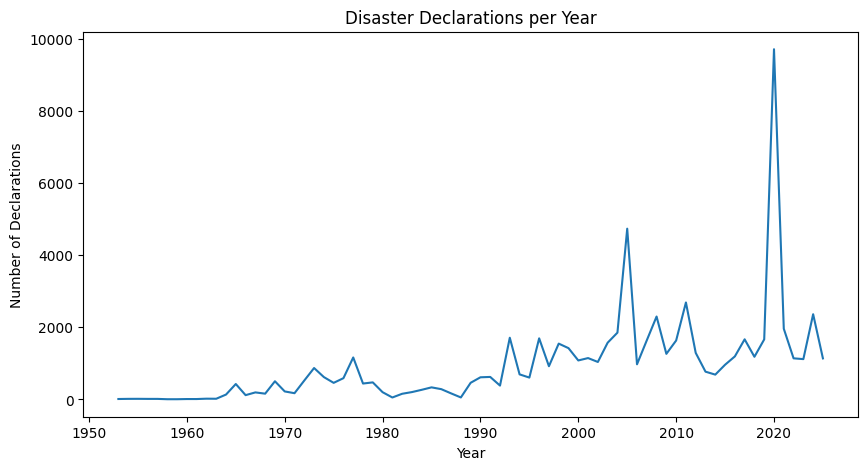

In [25]:
yearly_counts = df.groupby('year').size()

plt.figure(figsize=(10,5))
yearly_counts.plot()
plt.title("Disaster Declarations per Year")
plt.xlabel("Year")
plt.ylabel("Number of Declarations")
plt.show()

🔟 Declarations per State

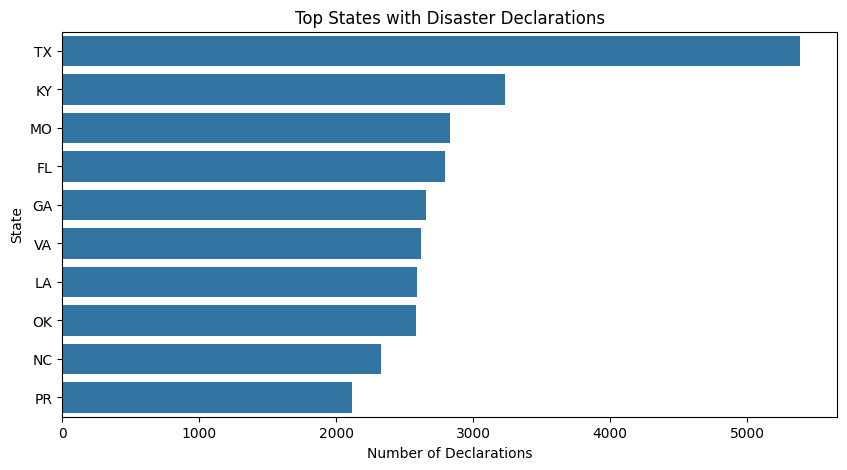

In [26]:
import seaborn as sns
state_counts = df['state'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=state_counts.values, y=state_counts.index)

plt.title("Top States with Disaster Declarations")
plt.xlabel("Number of Declarations")
plt.ylabel("State")
plt.show()

In Milestone-1, the FEMA disaster dataset was loaded and cleaned by handling missing values and formatting date columns. Initial exploratory analysis revealed patterns in disaster declarations across years and states. Preliminary visualizations highlighted increasing disaster frequency and state-level differences, providing a foundation for deeper analysis in later milestones.